In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import Model
import tensorflow as tf

import matplotlib.pyplot as plt

### Data load

In [2]:
url = 'https://raw.githubusercontent.com/JunetaeKim/DeepLearningClass/main/Dataset/iris.csv'
df = pd.read_csv(url, names=['sepal_length','sepal_width','petal_length','petal_width','species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Data preprocessing

In [3]:
Target = df.values[:, 4] # select target column
Features =  df.values[:, :4].astype('float32') # select feature columns

e = LabelEncoder() # Instantiation
e.fit(Target) # Fitting
Y = e.transform(Target) # Numeric encoding: Converting string labels to numeric labels


### Model define

In [4]:
def ModelStruc():
    
    Inp = Input(shape=(Features.shape[-1], ))
    Hidden1 = Dense(5, 'relu')(Inp)
    Hidden2 = Dense(3, 'tanh')(Hidden1)
    Output = Dense(3, 'softmax')(Hidden2)

    IrisMult = Model(Inp, Output)
    IrisMult.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',  metrics=['accuracy'])
    
    return IrisMult

### k-fold cross-validation setting

In [5]:
n_fold = 5
skf = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=0) # Instantiation


### Conduct k-fold cross-validation

In [6]:
TrAccuracy= []
ValAccuracy = []

for train, test in skf.split(Features,Y):
    
    Target_encoded = to_categorical(Y) # One-hot encoding
    
    IrisMult = ModelStruc()
    history = IrisMult.fit(Features[train].astype('float32'), Target_encoded[train], 
                           validation_data=(Features[test].astype('float32'), Target_encoded[test]),
                           epochs=100, batch_size=10, shuffle=True, verbose=2)
    
    TrAccuracy.append(history.history['accuracy'])
    ValAccuracy.append(history.history['val_accuracy'])

Epoch 1/100
12/12 - 2s - loss: 1.2787 - accuracy: 0.3333 - val_loss: 1.2667 - val_accuracy: 0.3333
Epoch 2/100
12/12 - 0s - loss: 1.2602 - accuracy: 0.3333 - val_loss: 1.2495 - val_accuracy: 0.3333
Epoch 3/100
12/12 - 0s - loss: 1.2424 - accuracy: 0.3333 - val_loss: 1.2349 - val_accuracy: 0.3333
Epoch 4/100
12/12 - 0s - loss: 1.2299 - accuracy: 0.3333 - val_loss: 1.2198 - val_accuracy: 0.3333
Epoch 5/100
12/12 - 0s - loss: 1.2144 - accuracy: 0.3333 - val_loss: 1.2073 - val_accuracy: 0.3333
Epoch 6/100
12/12 - 0s - loss: 1.2026 - accuracy: 0.3333 - val_loss: 1.1949 - val_accuracy: 0.3333
Epoch 7/100
12/12 - 0s - loss: 1.1893 - accuracy: 0.3333 - val_loss: 1.1830 - val_accuracy: 0.3333
Epoch 8/100
12/12 - 0s - loss: 1.1693 - accuracy: 0.3417 - val_loss: 1.1322 - val_accuracy: 0.5333
Epoch 9/100
12/12 - 0s - loss: 1.0557 - accuracy: 0.6417 - val_loss: 0.9692 - val_accuracy: 0.6667
Epoch 10/100
12/12 - 0s - loss: 0.9516 - accuracy: 0.6667 - val_loss: 0.9397 - val_accuracy: 0.6667
Epoch 11/

### Postprocessing for visualization

In [12]:
TrAccDF = pd.DataFrame(TrAccuracy).T
TrAccDF.columns = ['Fold: '+str(i) for i in range(1,6)]

ValAccDF = pd.DataFrame(ValAccuracy).T
ValAccDF.columns = ['Fold: '+str(i) for i in range(1,6)]

### Plot Tr_acc and Val_acc over epochs

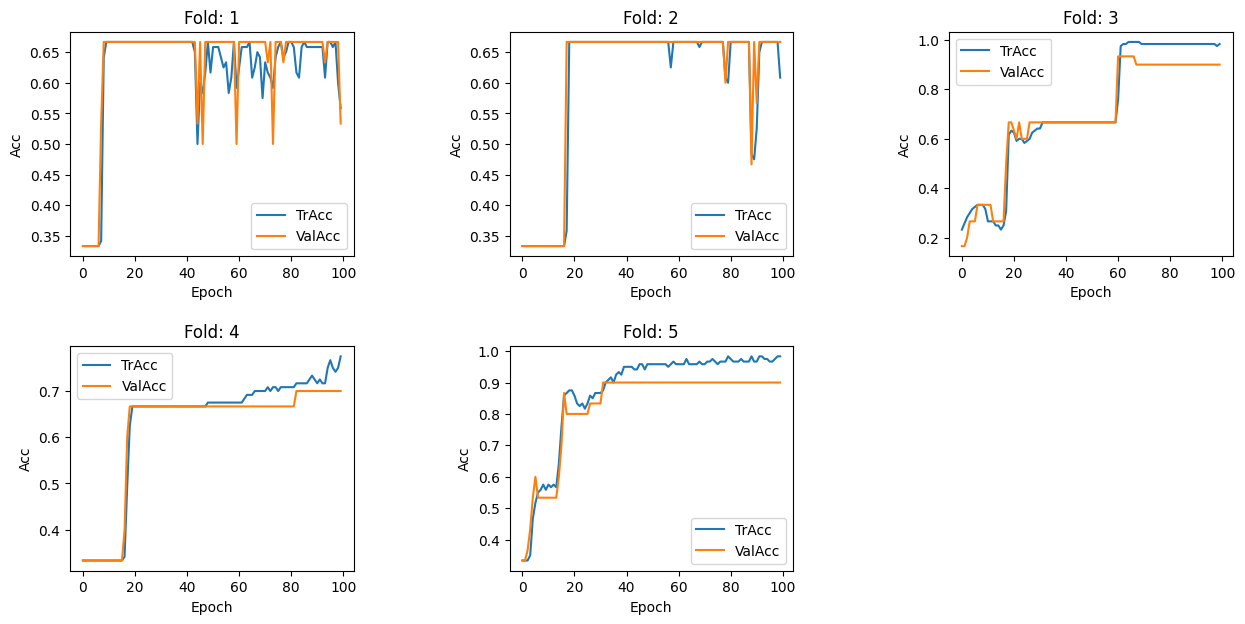

In [13]:
plt.figure(figsize=(15,7))
for num, i in enumerate(TrAccDF.columns):
    plt.subplot(2,3,num+1)
    plt.plot(TrAccDF[i], label='TrAcc')
    plt.plot(ValAccDF[i], label='ValAcc')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Acc')
    plt.subplots_adjust(wspace=0.55, hspace=0.4)
    plt.title(i)
